This is part 19 of a tutorial series. We recommend following them in order, starting with [Part 0: Welcome to `musica`](0.%20Welcome%20to%20MUSICA.ipynb).

# MIEM NOx Emissions Box Model

This tutorial uses `musica.miem`, MUSICA's emissions model, to drive a surface NO emission flux into TS1's chemistry in a single well-mixed box, building on [Part 11: TS1 Box Model](11.%20ts1_box_model.ipynb).

Each time step, a `musica.miem.Emissions` module computes a surface NO flux from a synthetic inventory. That flux sets the rate of a MICM `Emission` reaction feeding NO into TS1's mechanism, so emissions and chemistry are solved together.

## 1. Imports

In [10]:
import json
import tempfile
from datetime import datetime, time, timedelta
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import netCDF4
import pandas as pd
import pvlib
import ussa1976
import xarray as xr

import musica
from musica.mechanism_configuration import (
    Emission,
    EmissionsConfig,
    Inventory,
    Mechanism,
    Regridding,
    RegriddingType,
    SourceDescriptor,
    SourceMode,
    SourceType,
    SpeciesMap,
    SpeciesMapping,
    TemporalInterpolation,
    VerticalInjection,
    parse,
)
from musica.micm.solver_result import SolverState
from musica.miem import Emissions
from musica.tuvx import vTS1
from musica.utils import find_config_path

SECONDS_PER_HOUR = 3600
NO_MOLECULAR_WEIGHT = 0.030006  # kg mol-1

## 2. Location, Simulation Time, and Box Geometry

Same location as the Chapman/TS1 tutorials (Boulder, CO), using a single grid cell (index 1, skipping ground level 0) treated as a well-mixed box.

In [11]:
boulder = (40.01879858223568, -105.27492413846649)  # (latitude, longitude)
boulder_tz = ZoneInfo("America/Denver")

today_local = datetime.now(boulder_tz).date()
noon_local = datetime.combine(today_local, time(7, 30), tzinfo=boulder_tz)
sim_time = (noon_local - timedelta(hours=1)).astimezone(ZoneInfo("UTC"))

grid_cell_index = 1  # skip ground-level index 0, matching the chapman/ts1 tutorials
num_grid_cells = 1

# Representative surface NOx flux [kg m-2 s-1] for the synthetic inventory below --
# on the order of a moderately busy urban surface source.
NO_SURFACE_FLUX = 2.0e-9

# Height of the well-mixed box, used to convert surface flux into an emission rate.
BOX_HEIGHT_M = 100.0

print(f"Simulation start (UTC): {sim_time}")

Simulation start (UTC): 2026-07-22 12:30:00+00:00


## 3. TS1 Mechanism and Solver

We reuse TS1's mechanism and initial conditions (`configs/v1/ts1/`) as-is, adding one `Emission` reaction for NO so `miem` can drive it, and create the solver's state with a single grid cell instead of TS1's usual 10-level column.

In [12]:
mechanism = parse(find_config_path("v1", "ts1", "ts1.json"))
gas_phase = next(p for p in mechanism.phases if p.name == "gas")
no_species = next(s for s in mechanism.species if s.name == "NO")
mechanism.reactions = list(mechanism.reactions) + [Emission(name="NO", products=[no_species], gas_phase=gas_phase)]

solver = musica.MICM(mechanism=mechanism, solver_type=musica.SolverType.rosenbrock_standard_order)
state = solver.create_state(num_grid_cells)

## 4. Photolysis Rates from TUV-x

Same TS1 alias-mapping approach as [Part 11](11.%20ts1_box_model.ipynb), restricted to our single grid cell.

In [13]:
tuvx = vTS1.get_tuvx_calculator()

solpos = pvlib.solarposition.get_solarposition(time=sim_time, latitude=boulder[0], longitude=boulder[1])
sza = solpos['zenith'].item()
tuv_rates = tuvx.run(sza=np.deg2rad(sza), earth_sun_distance=1.0)

tuv_path = find_config_path("tuvx", "ts1_tsmlt.json")
with open(tuv_path, 'r') as f:
    tuv_config = json.load(f)
alias_mappings = tuv_config.get('__CAM options', {}).get('aliasing', {}).get('pairs', {})

photolysis_rate_constants = {}
for mapping in alias_mappings:
    label = mapping['to']
    scale = mapping.get("scale by", 1)
    tuv_label = mapping['from']
    rate = tuv_rates.sel(reaction=tuv_label).photolysis_rate_constants.values * scale
    photolysis_rate_constants[f'PHOTO.{label}'] = [rate[grid_cell_index]]

vertical_edge = tuv_rates.vertical_edge[grid_cell_index].item()
print(f"Grid cell altitude: {vertical_edge:.2f} km")

Grid cell altitude: 1.00 km


## 5. Initial Conditions

Reused directly from TS1's `initial_conditions.csv` -- including its real NO, NO2, and O3 starting concentrations.

In [14]:
conditions = pd.read_csv(
    find_config_path("v1", "ts1", "initial_conditions.csv"),
    sep=',', names=['parameter', 'value1', 'value2'],
    dtype={'parameter': str, 'value1': float, 'value2': float})

initial_concentrations = conditions[conditions['parameter'].str.contains('CONC')].copy()
initial_concentrations['parameter'] = initial_concentrations['parameter'].str.replace('CONC.', '', regex=False)

surface_reactions = conditions[conditions['parameter'].str.contains('SURF')]
user_defined_conditions = conditions[conditions['parameter'].str.contains('USER')]

concentration_dict = {row['parameter']: [row['value1']] for _, row in initial_concentrations.iterrows()}

user_defined_dict = {row['parameter']: [row['value1']] for _, row in user_defined_conditions.iterrows()}
for _, row in surface_reactions.iterrows():
    user_defined_dict[f"{row['parameter']}.effective radius [m]"] = [row['value1']]
    user_defined_dict[f"{row['parameter']}.particle number concentration [# m-3]"] = [row['value2']]
user_defined_dict.update(photolysis_rate_constants)

environmental_conditions = ussa1976.compute(z=np.array([vertical_edge * 1000]), variables=["t", "p"])
temperature = environmental_conditions['t'].values
pressure = environmental_conditions['p'].values

state.set_conditions(temperature, pressure)
state.set_concentrations(concentration_dict)
state.set_user_defined_rate_parameters(user_defined_dict)

print(f"Initial NO:  {concentration_dict['NO'][0]:.3e} mol m-3")
print(f"Initial NO2: {concentration_dict['NO2'][0]:.3e} mol m-3")
print(f"Initial O3:  {concentration_dict['O3'][0]:.3e} mol m-3")

Initial NO:  1.470e-08 mol m-3
Initial NO2: 6.370e-08 mol m-3
Initial O3:  2.490e-06 mol m-3


## 6. Build the Emissions Source with `musica.miem`

`EmissionsConfig` describes where the NO flux comes from: an inventory file, a species map from the inventory's variable name to the mechanism species `NO`, and a source tying them together.

The emissions module needs a NetCDF inventory file. We write a minimal synthetic single-snapshot file using the `uptempo` convention -- an `nCells` dimension plus a 1D flux variable named after the inventory species.

In [15]:
def write_synthetic_no_inventory(path, flux_value=NO_SURFACE_FLUX):
    ds = netCDF4.Dataset(str(path), "w", format="NETCDF4")
    try:
        ds.createDimension("nCells", 1)
        flux = ds.createVariable("no_surface", "f8", ("nCells",))
        flux[:] = np.array([flux_value])
    finally:
        ds.close()


def get_emissions(nc_path):
    emissions_config = EmissionsConfig(
        inventories=[
            Inventory(name="no inventory", directory="", file_pattern=str(nc_path), convention="uptempo"),
        ],
        species_maps=[
            SpeciesMap(
                name="no map",
                mappings=[SpeciesMapping(inventory_species="no_surface", mechanism_species="NO", scaling_factor=1.0)],
            ),
        ],
        regridding=Regridding(type=RegriddingType.None_),
        sources=[
            SourceDescriptor(
                name="no source",
                mode=SourceMode.Offline,
                type=SourceType.Anthropogenic,
                inventory="no inventory",
                species_map="no map",
                temporal_interpolation=TemporalInterpolation.None_,
                vertical_injection=VerticalInjection.Surface,
                category=0,
                hierarchy=1,
                scaling_factor=1.0,
                sector="anthropogenic",
            ),
        ],
    )
    emissions_mechanism = Mechanism(name="no emissions", emissions=emissions_config)
    return Emissions(mechanism=emissions_mechanism, n_cells=1, n_vert_levels=1)


tmp_dir = tempfile.mkdtemp()
nc_path = Path(tmp_dir) / "no_surface.nc"
write_synthetic_no_inventory(nc_path)
emissions = get_emissions(nc_path)

print(f"Emissions species: {list(emissions.species_names)}")

Emissions species: ['NO']


## 7. Run the Simulation

Each time step, `emissions.run(epoch_seconds, dt_seconds)` returns a surface NO flux `[kg m-2 s-1]`. We convert it into an emission rate `[mol m-3 s-1]` and set it as the NO `Emission` reaction's rate parameter, so MICM solves emissions and chemistry together.

In [16]:
sim_times = [sim_time]
concentrations = [state.get_concentrations()]
time_step = 30  # seconds
simulation_length = 3 * SECONDS_PER_HOUR
current_time = 0
last_printed_percent = -5

# Record the emission flux that drives the first step so the time series starts
# at the actual (constant) flux rather than a placeholder of zero.
no_index = list(emissions.species_names).index("NO")
no_flux_history = [emissions.run(sim_time.timestamp(), time_step)[no_index, 0]]

while current_time < simulation_length:
    flux = emissions.run(sim_time.timestamp(), time_step)
    no_index = list(emissions.species_names).index("NO")
    no_surface_flux = flux[no_index, 0]  # kg m-2 s-1, single cell

    no_emis_rate = no_surface_flux / (BOX_HEIGHT_M * NO_MOLECULAR_WEIGHT)  # mol m-3 s-1
    user_defined_dict["EMIS.NO"] = [no_emis_rate]
    state.set_user_defined_rate_parameters(user_defined_dict)

    elapsed = 0
    while elapsed < time_step:
        remaining_time = time_step - elapsed
        result = solver.solve(state, remaining_time)
        elapsed += result.stats.final_time
        current_time += result.stats.final_time
        if result.state != SolverState.Converged:
            print(f"Solver state: {result.state}, time: {current_time}")

    current_percent = (current_time / simulation_length) * 100
    if int(current_percent // 5) * 5 > last_printed_percent:
        last_printed_percent = int(current_percent // 5) * 5
        print(f"Simulation progress: {last_printed_percent}%")

    sim_time += timedelta(seconds=time_step)
    sim_times.append(sim_time)
    concentrations.append(state.get_concentrations())
    no_flux_history.append(no_surface_flux)

Simulation progress: 0%
Simulation progress: 5%
Simulation progress: 10%
Simulation progress: 15%
Simulation progress: 20%
Simulation progress: 25%
Simulation progress: 30%
Simulation progress: 35%
Simulation progress: 40%
Simulation progress: 45%
Simulation progress: 50%
Simulation progress: 55%
Simulation progress: 60%
Simulation progress: 65%
Simulation progress: 70%
Simulation progress: 75%
Simulation progress: 80%
Simulation progress: 85%
Simulation progress: 90%
Simulation progress: 95%
Simulation progress: 100%


## 8. Build the xarray Dataset

In [17]:
data_vars = {}
species_ordering = state.get_species_ordering()
for species in species_ordering:
    data_vars[species] = (["time"], [c[species][0] for c in concentrations])
data_vars["no_surface_flux"] = (["time"], no_flux_history, {"units": "kg m-2 s-1"})

coords = {"time": np.array([int(t.timestamp()) for t in sim_times], dtype="datetime64[s]")}
ds = xr.Dataset(data_vars, coords=coords)
ds

<xarray.Dataset> Size: 609kB
Dimensions:          (time: 361)
Coordinates:
  * time             (time) datetime64[s] 3kB 2026-07-22T12:30:00 ... 2026-07...
Data variables: (12/210)
    SOAG4            (time) float64 3kB 2.25e-08 2.252e-08 ... 2.281e-08
    SOAG2            (time) float64 3kB 1.4e-09 1.404e-09 ... 1.451e-09
    SOAG0            (time) float64 3kB 3.33e-11 4.152e-11 ... 1.971e-09
    NO3              (time) float64 3kB 9.32e-12 5.867e-12 ... 2.646e-14
    NO               (time) float64 3kB 1.47e-08 2.114e-08 ... 4.732e-06
    CL               (time) float64 3kB 1.07e-15 2.72e-16 ... 2.261e-17
    ...               ...
    EOOH             (time) float64 3kB 3.56e-09 3.564e-09 ... 3.55e-09
    CO2              (time) float64 3kB 0.0156 0.0156 0.0156 ... 0.0156 0.0156
    C3H7OOH          (time) float64 3kB 7.87e-11 7.877e-11 ... 7.715e-11
    NC4CHO           (time) float64 3kB 3.67e-11 3.594e-11 ... 1.435e-13
    MALO2            (time) float64 3kB 1.07e-13 8.101e-15 ... 2.499e-17
    no_surface_flux  (time) float64 3kB 2e-09 2e-09 2e-09 ... 2e-09 2e-09 2e-09

## 9. Plot Results

NO tracks the emitted flux directly; NO2 and O3 respond through TS1's real NOx-ozone chemistry.

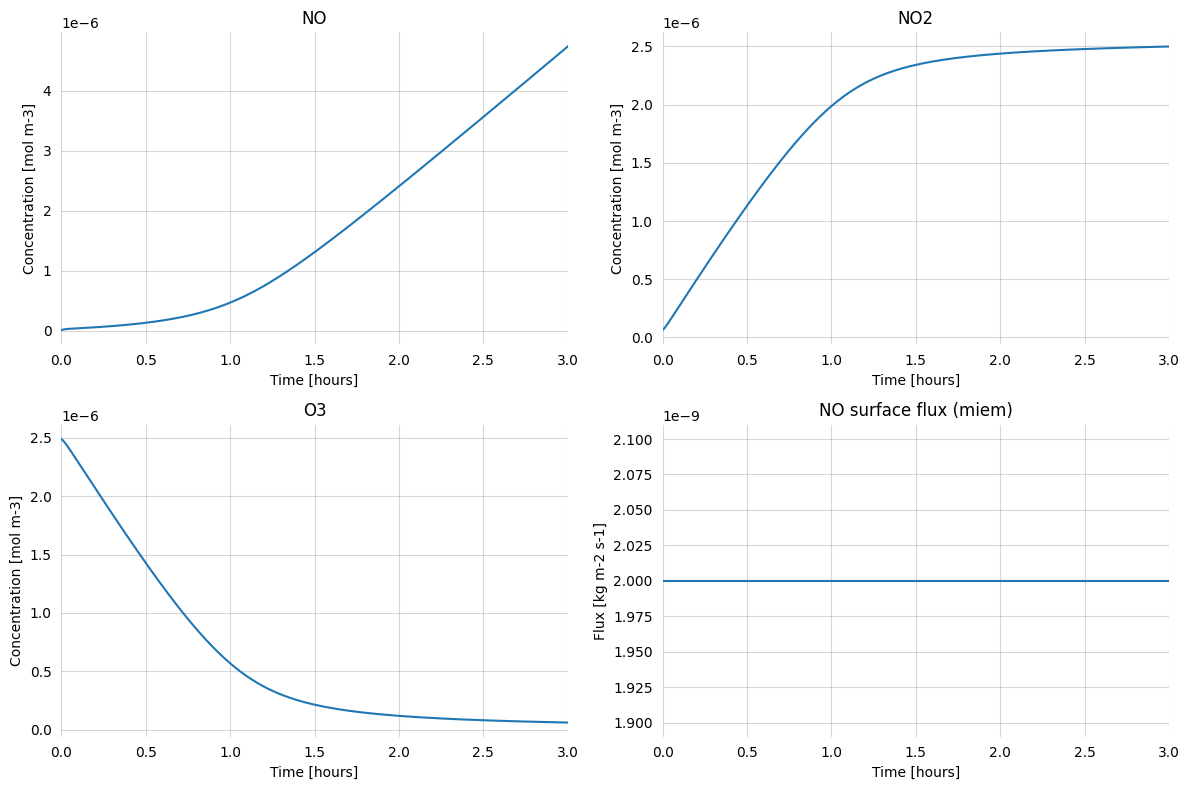

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
time_hours = (ds['time'] - ds['time'].isel(time=0)) / np.timedelta64(1, 'h')

axes[0, 0].plot(time_hours, ds['NO'])
axes[0, 0].set_title('NO')
axes[0, 1].plot(time_hours, ds['NO2'])
axes[0, 1].set_title('NO2')
axes[1, 0].plot(time_hours, ds['O3'])
axes[1, 0].set_title('O3')
axes[1, 1].plot(time_hours, ds['no_surface_flux'])
axes[1, 1].set_title('NO surface flux (miem)')
axes[1, 1].set_ylabel('Flux [kg m-2 s-1]')

for _ax in axes.flat[:3]:
    _ax.set_ylabel('Concentration [mol m-3]')
for _ax in axes.flat:
    _ax.grid(True, alpha=0.5)
    _ax.spines[:].set_visible(False)
    _ax.tick_params(width=0)
    _ax.set_xlim(0, simulation_length / SECONDS_PER_HOUR)
    _ax.set_xlabel('Time [hours]')

fig.tight_layout()